#Preparing



In [ ]:
import os
import io
import base64
import shutil
import random
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
)
from tensorflow.keras.models import Sequential, Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
from nltk.tokenize import word_tokenize

tf.autograph.set_verbosity(0) # Suppress Autograph warnings

print("All libraries imported.")

# Create directories for processed images
os.makedirs('New_Images_Processed', exist_ok=True)
os.makedirs('Damaged_Images_Processed', exist_ok=True)
print('Directories New_Images_Processed and Damaged_Images_Processed created.')

# Helper to decode base64 and save as JPEG
def decode_and_save_image(base64_string, target_dir, filename):
    try:
        if ',' in base64_string:
            _, encoded_data = base64_string.split(',', 1)
        else:
            encoded_data = base64_string

        image_bytes = base64.b64decode(encoded_data)
        image = Image.open(io.BytesIO(image_bytes))
        image = image.convert('RGB')
        file_path = os.path.join(target_dir, filename)
        image.save(file_path, 'JPEG')
    except (AttributeError, ValueError, TypeError, Image.UnidentifiedImageError, FileNotFoundError) as e:
        print(f"Error processing image {filename}: {e}. Skipping this image.")

print('Helper function decode_and_save_image defined.')

All libraries imported.
Directories New_Images_Processed and Damaged_Images_Processed created.
Helper function decode_and_save_image defined.


# Data Collection: Loading & Preparation

In [ ]:
# Load New Image Paths
df_new_images = pd.read_csv('/content/New_images.csv')
new_image_paths = df_new_images['Thumbnail Image']
print('Successfully loaded New_images.csv and extracted new_image_paths.')
print(f'First 5 new image paths:\n{new_image_paths.head()}')

# Load Damaged Image Paths
df_damaged_images = pd.read_csv('/content/damaged_images.csv')
damaged_image_paths = df_damaged_images['Thumbnail Image']
print('Successfully loaded damaged_images.csv and extracted damaged_image_paths.')
print(f'First 5 damaged image paths:\n{damaged_image_paths.head()}')

# Decode and save all NEW images
for i, base64_str in enumerate(new_image_paths):
    filename = f'new_image_{i}.jpeg'
    try:
        decode_and_save_image(base64_str, 'New_Images_Processed', filename)
    except OSError as e:
        print(f"Error processing image {filename} in loop: {e}. Skipping this image.")
print(f'Successfully processed {len(new_image_paths)} new images from New_Images.csv.')

# Decode and save all DAMAGED images
for i, base64_str in enumerate(damaged_image_paths):
    filename = f'damaged_base64_{i}.jpeg'
    try:
        decode_and_save_image(base64_str, 'Damaged_Images_Processed', filename)
    except OSError as e:
        print(f"Error processing image {filename} in loop: {e}. Skipping this image.")
print(f'Successfully processed {len(damaged_image_paths)} damaged images from damaged_images.csv.')

# Move any existing damaged_image_*.jpeg in /content to processed folder
for filename in os.listdir('/content/'):
    if filename.endswith('.jpeg') and filename.startswith('damaged_image_'):
        shutil.move(os.path.join('/content/', filename), 'Damaged_Images_Processed')
print('Successfully moved any unzipped damaged images to Damaged_Images_Processed directory.')

# Input Path for First Image (New) and Product Name/Description
user_image_path = 'New_Images_Processed/new_image_1.jpeg'
user_text_input_new = 'Laptop Pro 15-inch'
print(f"Using image path for NEW prediction: {user_image_path}")
print(f"Using product name/description (new): {user_text_input_new}")

# Input Path for Second Image (Damaged) and Product Name/Description
user_image_path_2 = 'Damaged_Images_Processed/damaged_base64_35.jpeg'
user_text_input_damaged = (
    'LUCID Memory Foam Soft and Breathable-Machine Washable Mattress Topper Cover, Queen, White'
)
print(f"Using image path for DAMAGED prediction: {user_image_path_2}")
print(f"Using product name/description (damaged): {user_text_input_damaged}")

Successfully loaded New_images.csv and extracted new_image_paths.
First 5 new image paths:
0    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
1    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
2    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
3    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
4    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
Name: Thumbnail Image, dtype: object
Successfully loaded damaged_images.csv and extracted damaged_image_paths.
First 5 damaged image paths:
0    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
1    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
2    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
3    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
4    data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...
Name: Thumbnail Image, dtype: object
Error processing image new_image_30.jpeg in loop: image file is truncated (0 bytes not processed). Skipping this image.
Error processing image new_image_31.jpeg: Incorrect padding. S

# Data Exploration & Visualization

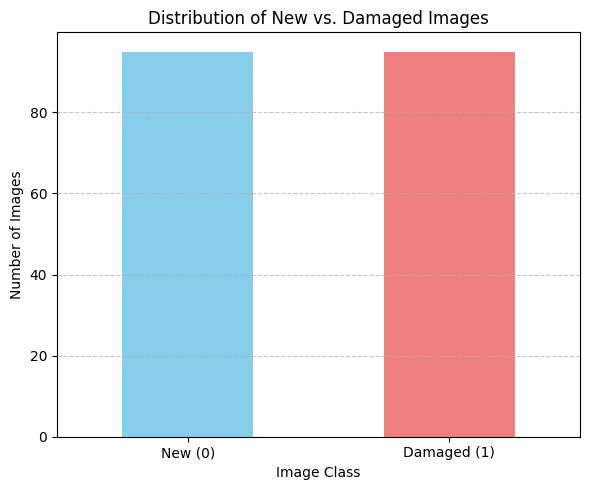

Class Counts:
 0    95
1    95
Name: count, dtype: int64


In [ ]:
class_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(6, 5))
class_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of New vs. Damaged Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.xticks(ticks=[0, 1], labels=['New (0)', 'Damaged (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Class Counts:\n", class_counts)

Number of new images: 95
Number of damaged images: 95


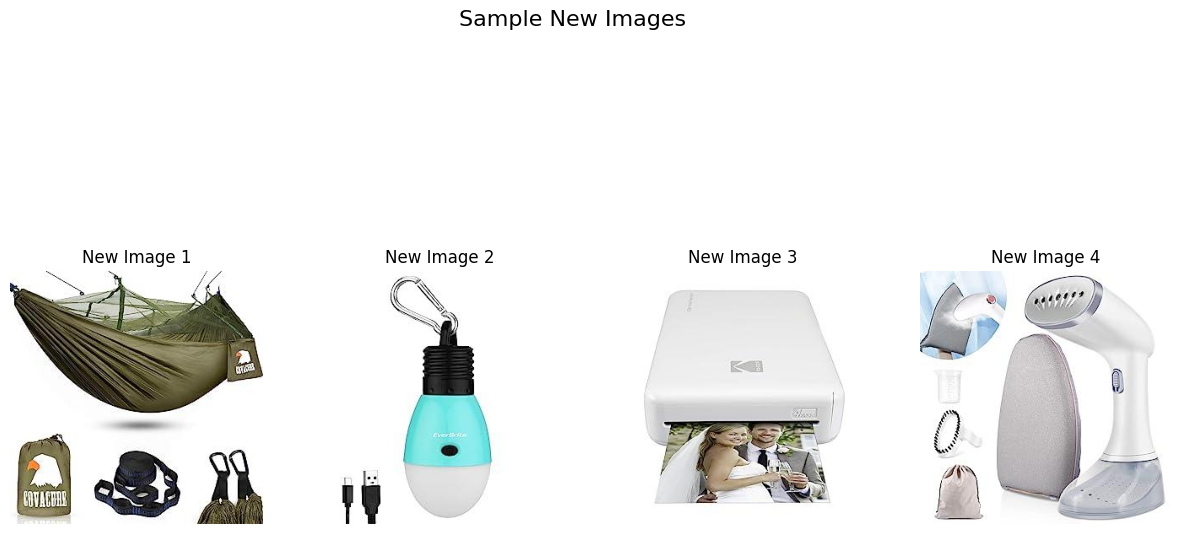

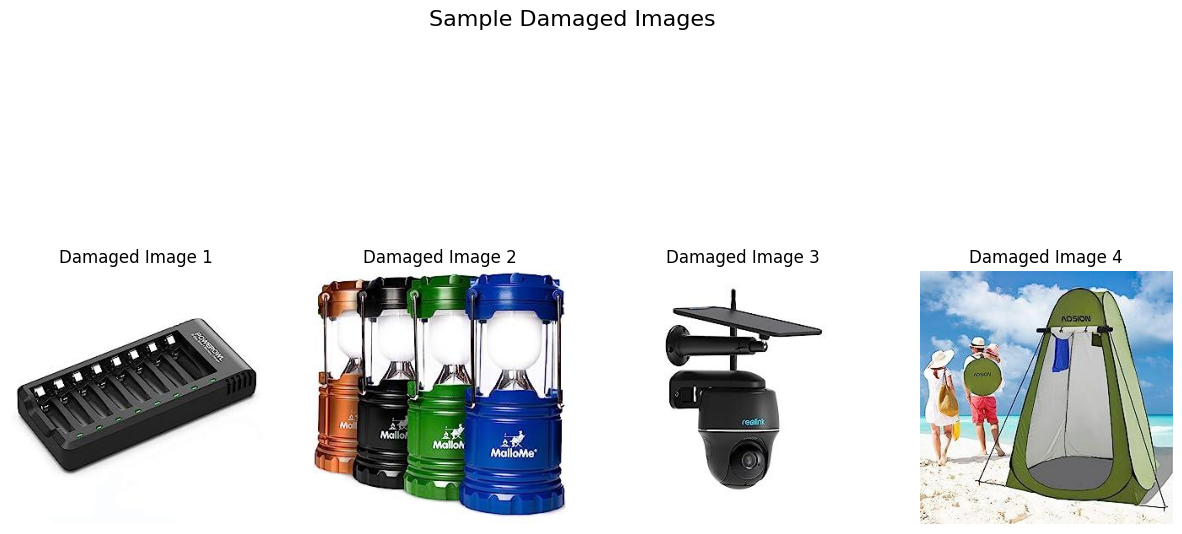

Successfully displayed sample images.


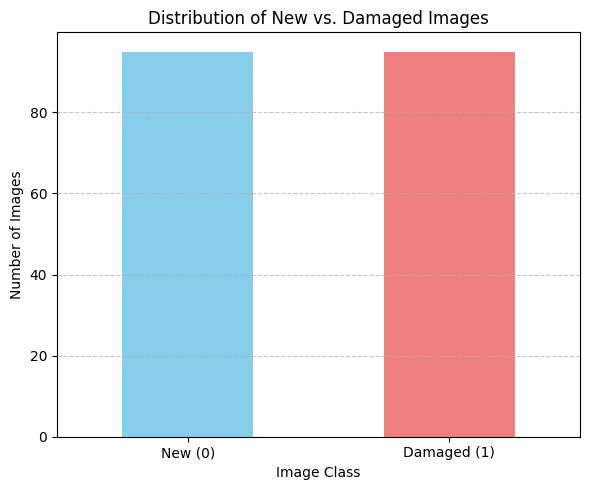

Class Counts:
 0    95
1    95
Name: count, dtype: int64
Total images collected: 190
Total labels collected: 190
First 5 image paths: ['New_Images_Processed/new_image_18.jpeg', 'New_Images_Processed/new_image_103.jpeg', 'New_Images_Processed/new_image_61.jpeg', 'New_Images_Processed/new_image_9.jpeg', 'New_Images_Processed/new_image_101.jpeg']
First 5 labels: [0, 0, 0, 0, 0]
Training set size: 133
Validation set size: 28
Test set size: 29
Class distribution in training set:
1    0.503759
0    0.496241
Name: proportion, dtype: float64
Class distribution in validation set:
0    0.5
1    0.5
Name: proportion, dtype: float64
Class distribution in test set:
0    0.517241
1    0.482759
Name: proportion, dtype: float64
Target image size defined as: (224, 224)
ImageDataGenerators defined.
Found 133 validated image filenames belonging to 2 classes.
Found 28 validated image filenames belonging to 2 classes.
Found 29 validated image filenames belonging to 2 classes.
Data generators created.


In [ ]:
import os
import io
import base64
import shutil
import random
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
)
from tensorflow.keras.models import Sequential, Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
from nltk.tokenize import word_tokenize

tf.autograph.set_verbosity(0) # Suppress Autograph warnings

# Explore and Visualize Data
new_images_count = len(os.listdir('New_Images_Processed'))
damaged_images_count = len(os.listdir('Damaged_Images_Processed'))
print(f"Number of new images: {new_images_count}")
print(f"Number of damaged images: {damaged_images_count}")

new_image_files = [
    os.path.join('New_Images_Processed', f)
    for f in os.listdir('New_Images_Processed') if f.endswith('.jpeg')
]
damaged_image_files = [
    os.path.join('Damaged_Images_Processed', f)
    for f in os.listdir('Damaged_Images_Processed') if f.endswith('.jpeg')
]

sample_size = 4
sample_new_images = random.sample(new_image_files, min(sample_size, len(new_image_files)))
sample_damaged_images = random.sample(damaged_image_files, min(sample_size, len(damaged_image_files)))

plt.figure(figsize=(15, 8))
plt.suptitle('Sample New Images', fontsize=16)
for i, img_path in enumerate(sample_new_images):
    img = Image.open(img_path)
    plt.subplot(1, sample_size, i + 1)
    plt.imshow(img)
    plt.title(f'New Image {i+1}')
    plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
plt.suptitle('Sample Damaged Images', fontsize=16)
for i, img_path in enumerate(sample_damaged_images):
    img = Image.open(img_path)
    plt.subplot(1, sample_size, i + 1)
    plt.imshow(img)
    plt.title(f'Damaged Image {i+1}')
    plt.axis('off')
plt.show()
print('Successfully displayed sample images.')

# Split Data and Apply Augmentation
image_paths = []
labels = []

for filename in os.listdir('New_Images_Processed'):
    if filename.endswith(('.jpeg', '.jpg', '.png')):
        image_paths.append(os.path.join('New_Images_Processed', filename))
        labels.append(0)

for filename in os.listdir('Damaged_Images_Processed'):
    if filename.endswith(('.jpeg', '.jpg', '.png')):
        image_paths.append(os.path.join('Damaged_Images_Processed', filename))
        labels.append(1)

# Plotting distribution of New vs. Damaged Images (moved from previous cell)
class_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(6, 5))
class_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of New vs. Damaged Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.xticks(ticks=[0, 1], labels=['New (0)', 'Damaged (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Class Counts:\n", class_counts)

print(f"Total images collected: {len(image_paths)}")
print(f"Total labels collected: {len(labels)}")
print(f"First 5 image paths: {image_paths[:5]}")
print(f"First 5 labels: {labels[:5]}")

image_paths = np.array(image_paths)
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")
print("Class distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Class distribution in validation set:")
print(pd.Series(y_val).value_counts(normalize=True))
print("Class distribution in test set:")
print(pd.Series(y_test).value_counts(normalize=True))

TARGET_SIZE = (224, 224)
print(f"Target image size defined as: {TARGET_SIZE}")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)
print('ImageDataGenerators defined.')

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_train, 'class': y_train.astype(str)}),
    x_col='filename',
    y_col='class',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

validation_generator = val_test_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_val, 'class': y_val.astype(str)}),
    x_col='filename',
    y_col='class',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_test, 'class': y_test.astype(str)}),
    x_col='filename',
    y_col='class',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42,
    shuffle=False
)
print('Data generators created.')

# Text Data Processing

In [ ]:
# Create dummy product_data.csv and load
dummy_data = {
    'product_name': [
        'Laptop Pro 15-inch', 'Smartphone X', 'Wireless Earbuds',
        'Smartwatch 2.0', 'Portable Speaker'
    ]
}
df_dummy = pd.DataFrame(dummy_data)
df_dummy.to_csv('/content/product_data.csv', index=False)

df_text_data = pd.read_csv('/content/product_data.csv')
print('product_data.csv created and loaded.')
print(df_text_data.head())

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab/english/')
except LookupError:
    nltk.download('punkt_tab')

def preprocess_text(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = word_tokenize(text)
    return tokens

df_text_data['processed_product_name'] = df_text_data['product_name'].apply(preprocess_text)
print('Basic text preprocessing applied.')
print(df_text_data[['product_name', 'processed_product_name']].head())

# Synthetic labeled text dataset for text classifier
text_classification_data = {
    'product_name': [
        'new laptop, no damage', 'broken screen, damaged phone',
        'pristine smartwatch', 'scratched earbuds, faulty',
        'brand new portable speaker', 'damaged item, box torn',
        'perfect condition tablet', 'cracked lens camera',
        'new keyboard, sealed', 'damaged mouse, not working'
    ],
    'label': ['new', 'damaged', 'new', 'damaged', 'new',
              'damaged', 'new', 'damaged', 'new', 'damaged']
}
df_text_labels = pd.DataFrame(text_classification_data)

def preprocess_text_for_vectorizer(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = word_tokenize(text)
    return " ".join(tokens)

df_text_labels['processed_text'] = df_text_labels['product_name'].apply(
    preprocess_text_for_vectorizer
)

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df_text_labels['processed_text'],
    df_text_labels['label'],
    test_size=0.3,
    random_state=42,
    stratify=df_text_labels['label']
)

tfidf_vectorizer = TfidfVectorizer(max_features=100)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

text_model = LogisticRegression(random_state=42)
text_model.fit(X_train_tfidf, y_train_text)

print('Text Classification Model Performance on synthetic data:')
y_pred_text = text_model.predict(X_test_tfidf)
print(classification_report(y_test_text, y_pred_text))

df_text_data['preprocessed_for_model'] = df_text_data['product_name'].apply(
    preprocess_text_for_vectorizer
)
df_text_data_vectorized = tfidf_vectorizer.transform(
    df_text_data['preprocessed_for_model']
)

class_labels = text_model.classes_
prob_damaged_idx = np.where(class_labels == 'damaged')[0][0]
prob_new_idx = np.where(class_labels == 'new')[0][0]

df_text_data['text_prediction_proba_damaged'] = text_model.predict_proba(
    df_text_data_vectorized)[:, prob_damaged_idx]
df_text_data['text_prediction_proba_new'] = text_model.predict_proba(
    df_text_data_vectorized)[:, prob_new_idx]
df_text_data['text_prediction_class'] = text_model.predict(
    df_text_data_vectorized
)

print('Predictions for df_text_data:')
print(df_text_data[['product_name', 'text_prediction_class',
                    'text_prediction_proba_damaged',
                    'text_prediction_proba_new']].head())
print(f"Shape of text embeddings: {df_text_data_vectorized.shape}")


product_data.csv created and loaded.
         product_name
0  Laptop Pro 15-inch
1        Smartphone X
2    Wireless Earbuds
3      Smartwatch 2.0
4    Portable Speaker


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Basic text preprocessing applied.
         product_name processed_product_name
0  Laptop Pro 15-inch  [laptop, pro, 15inch]
1        Smartphone X        [smartphone, x]
2    Wireless Earbuds    [wireless, earbuds]
3      Smartwatch 2.0       [smartwatch, 20]
4    Portable Speaker    [portable, speaker]
Text Classification Model Performance on synthetic data:
              precision    recall  f1-score   support

     damaged       1.00      0.50      0.67         2
         new       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

Predictions for df_text_data:
         product_name text_prediction_class  text_prediction_proba_damaged  \
0  Laptop Pro 15-inch                   new                       0.382631   
1        Smartphone X                   new                       0.424210   
2    Wireless Earbuds                   new     

# Model Design & Training

* **VGG16 model**
* **ResNet50 Model**
* **Custom CNN model**

In [ ]:
# Implement and Train VGG16 Model
vgg_base = VGG16(weights='imagenet', include_top=False,
                 input_shape=TARGET_SIZE + (3,))
for layer in vgg_base.layers:
    layer.trainable = False

x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
vgg_predictions = Dense(1, activation='sigmoid')(x)
vgg_model = Model(inputs=vgg_base.input, outputs=vgg_predictions)
vgg_model.compile(
    optimizer='adam', loss='binary_crossentropy',
    metrics=['accuracy'], run_eagerly=True
)
vgg_model.summary()
print('VGG16 model ready.')

# Implement and Train ResNet50 Model
resnet_base = ResNet50(weights='imagenet', include_top=False,
                       input_shape=TARGET_SIZE + (3,))
for layer in resnet_base.layers:
    layer.trainable = False

x_r = resnet_base.output
x_r = Flatten()(x_r)
x_r = Dense(256, activation='relu')(x_r)
resnet_predictions = Dense(1, activation='sigmoid')(x_r)
resnet_model = Model(inputs=resnet_base.input, outputs=resnet_predictions)
resnet_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
resnet_model.summary()
print('ResNet50 model ready.')

# Implement and Train Custom CNN Model
custom_cnn_model = Sequential([
    Input(shape=TARGET_SIZE + (3,)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu', name='dense_6'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
custom_cnn_model.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])
custom_cnn_model.summary()
print('Custom CNN model ready.')

EPOCHS = 5

print('Training VGG16 model...')
vgg_history = vgg_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)
print('VGG16 training complete.')

print('Training ResNet50 model...')
resnet_history = resnet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)
print('ResNet50 training complete.')

print('Training Custom CNN model...')
custom_cnn_history = custom_cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)
print('Custom CNN training complete.')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

Custom CNN model ready.
Training VGG16 model...
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 312s 59s/step - accuracy: 0.5338 - loss: 4.7492 - val_accuracy: 0.5000 - val_loss: 2.0992
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 300s 58s/step - accuracy: 0.5134 - loss: 1.6102 - val_accuracy: 0.4643 - val_loss: 0.8448
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 305s 73s/step - accuracy: 0.5131 - loss: 0.9136 - val_accuracy: 0.5357 - val_loss: 1.0829
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 319s 58s/step - accuracy: 0.5017 - loss: 0.9649 - val_accuracy: 0.4643 - val_loss: 1.0211
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 296s 57s/step - accuracy: 0.5273 - loss: 0.7926 - val_accuracy: 0.5357 - val_loss: 1.2583
VGG16 training complete.
Training ResNet50 model...
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.4821 - loss: 12.5906 - val_accuracy: 0.5000 - val_loss: 11.9481
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 6s/step - accuracy: 0.4996 - loss: 9.4693 - val_accuracy: 0.5000 - val_loss: 2.7006
Epoch 3/5
5/5 ━━━━━━━━━━━━━

# Model Evaluation

Evaluating VGG16 on test set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.3448 - loss: 1.4701
VGG16 Test Loss: 1.4701
VGG16 Test Accuracy: 0.3448
Evaluating ResNet50 on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4828 - loss: 0.7365
ReSNet50 Test Loss: 0.7365
ReSNet50 Test Accuracy: 0.4828
Evaluating Custom CNN on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4828 - loss: 0.6952
Custom CNN Test Loss: 0.6952
Custom CNN Test Accuracy: 0.4828
Computing predictions for classification reports...
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- VGG16 Model Performance ---
              precision    recall  f1-score   support

           0       0.42      0.67      0.51        15
           1       0.00      0.00      0.00        14

    accuracy                           0.34        29
   macro avg       0.21      0.33      0.26        29
weighted avg       0.22      0.34      0.27        29



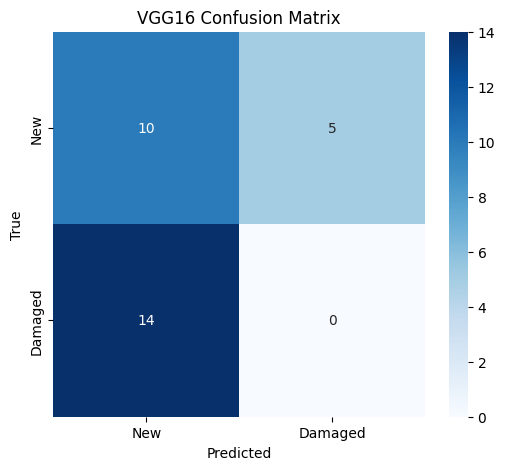


--- ResNet50 Model Performance ---
              precision    recall  f1-score   support

           0       0.50      0.67      0.57        15
           1       0.44      0.29      0.35        14

    accuracy                           0.48        29
   macro avg       0.47      0.48      0.46        29
weighted avg       0.47      0.48      0.46        29



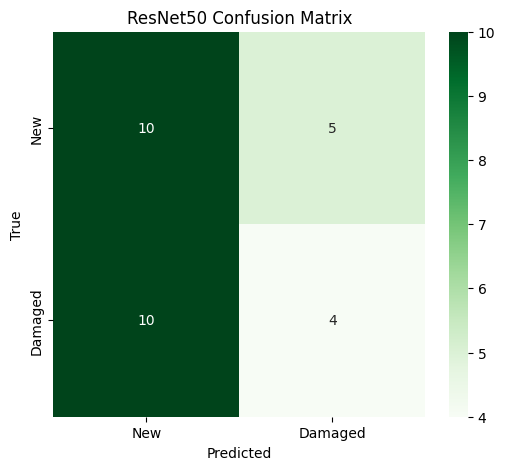


--- Custom CNN Model Performance ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.48      1.00      0.65        14

    accuracy                           0.48        29
   macro avg       0.24      0.50      0.33        29
weighted avg       0.23      0.48      0.31        29



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


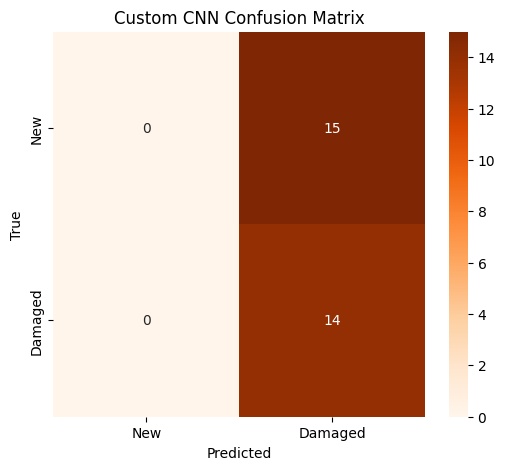

Classification reports and confusion matrices generated.


In [ ]:
print('Evaluating VGG16 on test set...')
vgg_eval = vgg_model.evaluate(test_generator, verbose=1)
print(f'VGG16 Test Loss: {vgg_eval[0]:.4f}')
print(f'VGG16 Test Accuracy: {vgg_eval[1]:.4f}')

print('Evaluating ResNet50 on test set...')
resnet_eval = resnet_model.evaluate(test_generator, verbose=1)
print(f'ReSNet50 Test Loss: {resnet_eval[0]:.4f}')
print(f'ReSNet50 Test Accuracy: {resnet_eval[1]:.4f}')

print('Evaluating Custom CNN on test set...')
custom_cnn_eval = custom_cnn_model.evaluate(test_generator, verbose=1)
print(f'Custom CNN Test Loss: {custom_cnn_eval[0]:.4f}')
print(f'Custom CNN Test Accuracy: {custom_cnn_eval[1]:.4f}')

print('Computing predictions for classification reports...')
vgg_pred_probs = vgg_model.predict(test_generator)
vgg_pred_labels = (vgg_pred_probs > 0.5).astype(int)

resnet_pred_probs = resnet_model.predict(test_generator)
resnet_pred_labels = (resnet_pred_probs > 0.5).astype(int)

custom_cnn_pred_probs = custom_cnn_model.predict(test_generator)
custom_cnn_pred_labels = (custom_cnn_pred_probs > 0.5).astype(int)

y_true = test_generator.classes

print('\n--- VGG16 Model Performance ---')
print(classification_report(y_true, vgg_pred_labels))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, vgg_pred_labels),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['New', 'Damaged'],
            yticklabels=['New', 'Damaged'])
plt.title('VGG16 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print('\n--- ResNet50 Model Performance ---')
print(classification_report(y_true, resnet_pred_labels))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, resnet_pred_labels),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['New', 'Damaged'],
            yticklabels=['New', 'Damaged'])
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print('\n--- Custom CNN Model Performance ---')
print(classification_report(y_true, custom_cnn_pred_labels))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, custom_cnn_pred_labels),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['New', 'Damaged'],
            yticklabels=['New', 'Damaged'])
plt.title('Custom CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print('Classification reports and confusion matrices generated.')


# Image Feature Extraction (for multimodal part)

In [ ]:
import requests
from PIL import Image
from io import BytesIO

def preprocess_image(image_path):
    try:
        if image_path.startswith('http://') or image_path.startswith('https://'):
            response = requests.get(image_path)
            response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            img = Image.open(image_path).convert('RGB')

        img = img.resize(TARGET_SIZE)
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image from {image_path}: {e}")
        return None
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

processed_image_new = preprocess_image(user_image_path)
processed_image = preprocess_image(user_image_path_2)

if processed_image_new is not None:
    print(f"New preprocessed image shape: {processed_image_new.shape}")
if processed_image is not None:
    print(f"Second preprocessed image shape: {processed_image.shape}")

# Predict probabilities for both images using the custom CNN
if processed_image_new is not None:
    prediction_probability_new = custom_cnn_model.predict(processed_image_new)[0][0]
    print(f"Prediction probability for new image (Custom CNN): {prediction_probability_new:.4f}")
else:
    prediction_probability_new = None

if processed_image is not None:
    prediction_probability = custom_cnn_model.predict(processed_image)[0][0]
    print(f"Prediction probability for second image (Custom CNN): {prediction_probability:.4f}")
else:
    prediction_probability = None

# Simple refund eligibility logic for new and damaged images
if processed_image_new is not None and prediction_probability_new is not None:
    THRESHOLD_DAMAGED = 0.8
    THRESHOLD_NEW = 0.66
    if prediction_probability_new >= THRESHOLD_DAMAGED:
        classification_new = 'Damaged'
        refund_eligibility_new = 'Eligible for Refund (High Confidence)'
    elif prediction_probability_new <= THRESHOLD_NEW:
        classification_new = 'New'
        refund_eligibility_new = 'Not Eligible for Refund (High Confidence)'
    else:
        classification_new = 'Uncertain'
        refund_eligibility_new = 'Requires Manual Review'
    print(f"\nImage Classification (New Image): {classification_new}")
    print(f"Refund Eligibility (New Image): {refund_eligibility_new}")

if processed_image is not None and prediction_probability is not None:
    THRESHOLD_DAMAGED_2 = 0.7
    THRESHOLD_NEW_2 = 0.3
    if prediction_probability >= THRESHOLD_DAMAGED_2:
        classification = 'Damaged'
        refund_eligibility = 'Eligible for Refund (High Confidence)'
    elif prediction_probability <= THRESHOLD_NEW_2:
        classification = 'New'
        refund_eligibility = 'Not Eligible for Refund (High Confidence)'
    else:
        classification = 'Uncertain'
        refund_eligibility = 'Requires Manual Review'
    print(f"\nImage Classification (Second Image): {classification}")
    print(f"Refund Eligibility (Second Image): {refund_eligibility}")

    # Extract features from penultimate dense layer of custom CNN
feature_extractor = Model(
    inputs=custom_cnn_model.layers[0].input,
    outputs=custom_cnn_model.get_layer('dense_6').output
)

if processed_image_new is not None:
    image_features_new = feature_extractor.predict(processed_image_new)
    print(f"Shape of image features for new image: {image_features_new.shape}")
else:
    image_features_new = None

if processed_image is not None:
    image_features_damaged = feature_extractor.predict(processed_image)
    print(f"Shape of image features for damaged image: {image_features_damaged.shape}")
else:
    image_features_damaged = None

# Select first two text feature rows for pairing
text_features_new = df_text_data_vectorized.toarray()[0].reshape(1, -1)
text_features_damaged = df_text_data_vectorized.toarray()[1].reshape(1, -1)
print(f"Shape of text features for new image: {text_features_new.shape}")
print(f"Shape of text features for damaged image: {text_features_damaged.shape}")

if image_features_new is not None:
    combined_features_new = np.concatenate((image_features_new, text_features_new), axis=1)
    print(f"Shape of combined features for new image: {combined_features_new.shape}")
else:
    combined_features_new = None

if image_features_damaged is not None:
    combined_features_damaged = np.concatenate((image_features_damaged, text_features_damaged), axis=1)
    print(f"Shape of combined features for damaged image: {combined_features_damaged.shape}")
else:
    combined_features_damaged = None

New preprocessed image shape: (1, 224, 224, 3)
Second preprocessed image shape: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Prediction probability for new image (Custom CNN): 0.5077
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction probability for second image (Custom CNN): 0.5070

Image Classification (New Image): New
Refund Eligibility (New Image): Not Eligible for Refund (High Confidence)

Image Classification (Second Image): Uncertain
Refund Eligibility (Second Image): Requires Manual Review
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Shape of image features for new image: (1, 512)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Shape of image features for damaged image: (1, 512)
Shape of text features for new image: (1, 22)
Shape of text features for damaged image: (1, 22)
Shape of combined features for new image: (1, 534)
Shape of combined features for damaged image: (1, 534)


# Train a Simple Multimodal Classifier (Logistic Regression)

In [ ]:
num_samples_per_class = 50
num_image_features = 512
num_text_features = 22

synthetic_image_features_new = np.random.rand(num_samples_per_class, num_image_features)
synthetic_text_features_new = np.random.rand(num_samples_per_class, num_text_features)
synthetic_labels_new = np.zeros(num_samples_per_class)

synthetic_image_features_damaged = np.random.rand(num_samples_per_class, num_image_features)
synthetic_text_features_damaged = np.random.rand(num_samples_per_class, num_text_features)
synthetic_labels_damaged = np.ones(num_samples_per_class)

X_synthetic_image = np.concatenate(
    (synthetic_image_features_new, synthetic_image_features_damaged), axis=0
)
X_synthetic_text = np.concatenate(
    (synthetic_text_features_new, synthetic_text_features_damaged), axis=0
)
y_synthetic = np.concatenate(
    (synthetic_labels_new, synthetic_labels_damaged), axis=0
)

X_synthetic_combined = np.concatenate(
    (X_synthetic_image, X_synthetic_text), axis=1
)
print(f"Shape of synthetic combined features: {X_synthetic_combined.shape}")
print(f"Shape of synthetic labels: {y_synthetic.shape}")

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_synthetic_combined, y_synthetic, test_size=0.2,
    random_state=42, stratify=y_synthetic
)

print(f"Shape of multimodal training features: {X_train_multi.shape}")
print(f"Shape of multimodal testing features: {X_test_multi.shape}")

multimodal_classifier = LogisticRegression(
    random_state=42, max_iter=200
)
multimodal_classifier.fit(X_train_multi, y_train_multi)

y_pred_multi = multimodal_classifier.predict(X_test_multi)
print('\nMultimodal Classifier Performance on synthetic test data:')
print(classification_report(y_test_multi, y_pred_multi))
print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_multi):.4f}")
print('Multimodal classifier trained.')

Shape of synthetic combined features: (100, 534)
Shape of synthetic labels: (100,)
Shape of multimodal training features: (80, 534)
Shape of multimodal testing features: (20, 534)

Multimodal Classifier Performance on synthetic test data:
              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60        10
         1.0       0.60      0.60      0.60        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20

Accuracy: 0.6000
Multimodal classifier trained.



--- Multimodal Classifier Performance ---
              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60        10
         1.0       0.60      0.60      0.60        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



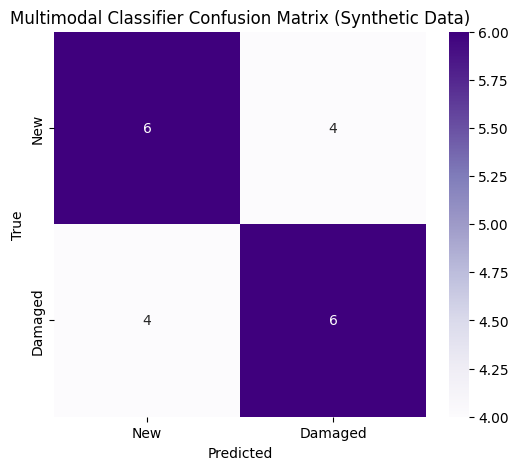

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Assuming pandas is needed for pd.Series, if not already globally imported

print('\n--- Multimodal Classifier Performance ---')
print(classification_report(y_test_multi, y_pred_multi, zero_division=0))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_multi, y_pred_multi),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['New', 'Damaged'],
            yticklabels=['New', 'Damaged'])
plt.title('Multimodal Classifier Confusion Matrix (Synthetic Data)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Prediction – Multimodal (Image + Text)

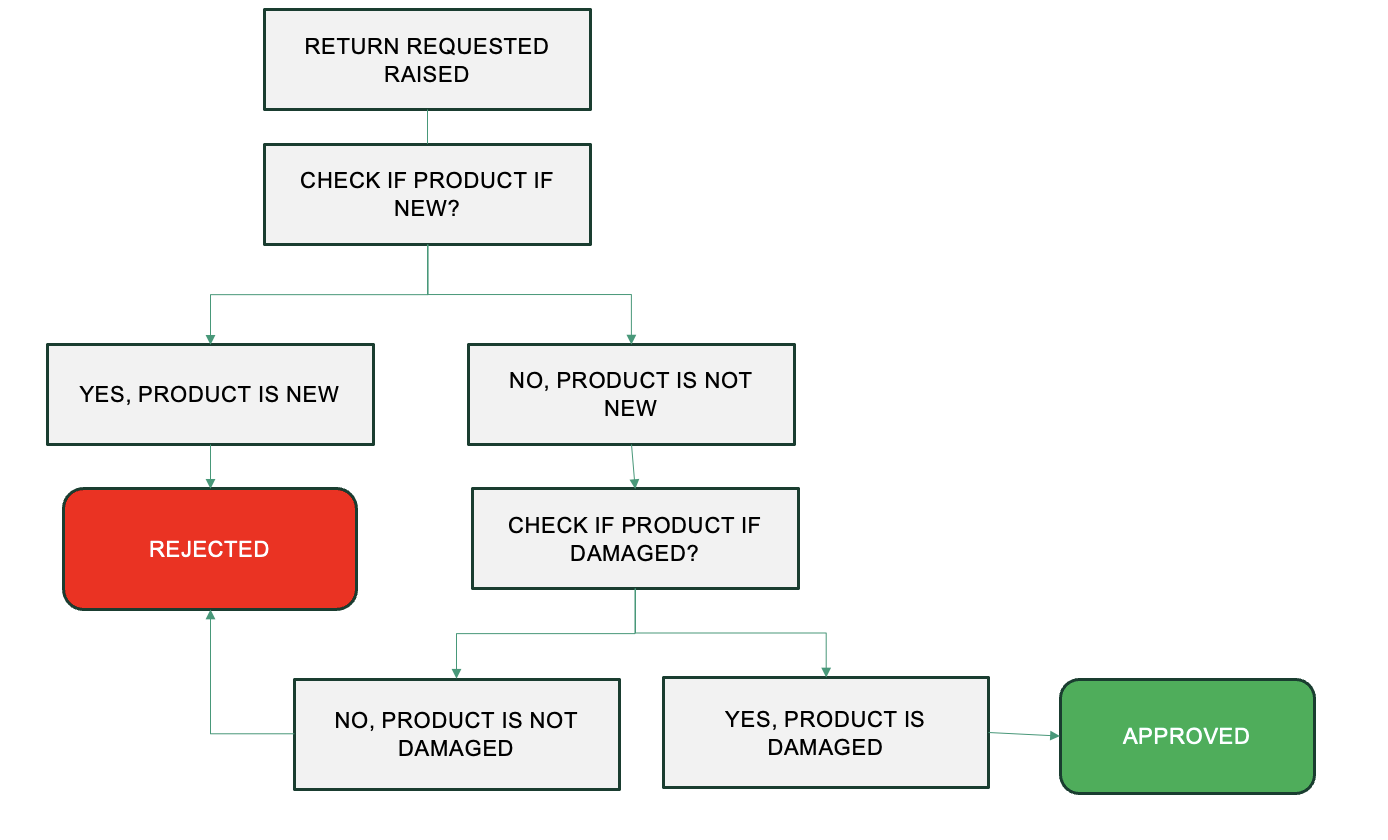

In [ ]:
preprocessed_user_text_input = preprocess_text_for_vectorizer(user_text_input_new)
user_text_features_new_input = tfidf_vectorizer.transform(
    [preprocessed_user_text_input]).toarray()

preprocessed_user_text_input_damaged = preprocess_text_for_vectorizer(
    user_text_input_damaged
)
user_text_features_damaged_input = tfidf_vectorizer.transform(
    [preprocessed_user_text_input_damaged]).toarray()

# Combine CNN image features with text features for user inputs
if image_features_new is not None and user_text_features_new_input is not None:
    combined_features_new_user_input = np.concatenate(
        (image_features_new, user_text_features_new_input), axis=1
    )
else:
    combined_features_new_user_input = None

if image_features_damaged is not None and user_text_features_damaged_input is not None:
    combined_features_damaged_user_input = np.concatenate(
        (image_features_damaged, user_text_features_damaged_input), axis=1
    )
else:
    combined_features_damaged_user_input = None

if combined_features_new_user_input is not None:
    prediction_multimodal_new_user = multimodal_classifier.predict(
        combined_features_new_user_input)[0]
    prediction_proba_multimodal_new_user = multimodal_classifier.predict_proba(
        combined_features_new_user_input)[0]
    predicted_class_new_user = 'New' if prediction_multimodal_new_user == 0 else 'Damaged'
    predicted_proba_damaged_new_user = prediction_proba_multimodal_new_user[1]

In [ ]:
# @title # 1. Define the variables for user input
user_image_path = '/content/New_Images_Processed/new_image_101.jpeg' # @param {type:"string"}
user_text_input = 'EUBSWA Camouflage Solar Shower Bag, 5 gallons/20L Solar Heating Camping Shower Water Bag Temperature 45¬∞C with Removable Hose Shower Head, Outdoor Camping Hiking Climbing Shower' # @param {type:"string"}


print(f"Using image path for prediction: {user_image_path}")
print(f"Using product name/description for prediction: {user_text_input}")

Using image path for prediction: /content/New_Images_Processed/new_image_101.jpeg
Using product name/description for prediction: EUBSWA Camouflage Solar Shower Bag, 5 gallons/20L Solar Heating Camping Shower Water Bag Temperature 45¬∞C with Removable Hose Shower Head, Outdoor Camping Hiking Climbing Shower


In [ ]:
# 2. Preprocess the image
processed_image_prediction = preprocess_image(user_image_path)

# 3. Extract image features
image_features_prediction = None
if processed_image_prediction is not None:
    # Ensure feature_extractor is initialized (it was in Pro7J-e0oMi6, but re-initializing for robustness)
    try:
        _ = feature_extractor
    except NameError:
        feature_extractor = Model(
            inputs=custom_cnn_model.layers[0].input,
            outputs=custom_cnn_model.get_layer('dense_6').output
        )
    image_features_prediction = feature_extractor.predict(processed_image)
    print(f"Shape of image features for prediction: {image_features_prediction.shape}")
else:
    print(f"Image preprocessing failed for {user_image_path}.")

# 4. Preprocess the text
preprocessed_user_text_input = preprocess_text_for_vectorizer(user_text_input)
print(f"Preprocessed text for prediction: {preprocessed_user_text_input}")

# 5. Vectorize the preprocessed text
user_text_features_prediction = tfidf_vectorizer.transform(
    [preprocessed_user_text_input]).toarray()
print(f"Shape of text features for prediction: {user_text_features_prediction.shape}")

# 6. Combine image and text features
combined_features_prediction = None
if image_features_prediction is not None and user_text_features_prediction is not None:
    combined_features_prediction = np.concatenate(
        (image_features_prediction, user_text_features_prediction), axis=1
    )
    print(f"Shape of combined features for prediction: {combined_features_prediction.shape}")
else:
    print("Cannot combine features: either image or text features are missing.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Shape of image features for prediction: (1, 512)
Preprocessed text for prediction: eubswa camouflage solar shower bag 5 gallons20l solar heating camping shower water bag temperature 45¬∞c with removable hose shower head outdoor camping hiking climbing shower
Shape of text features for prediction: (1, 22)
Shape of combined features for prediction: (1, 534)


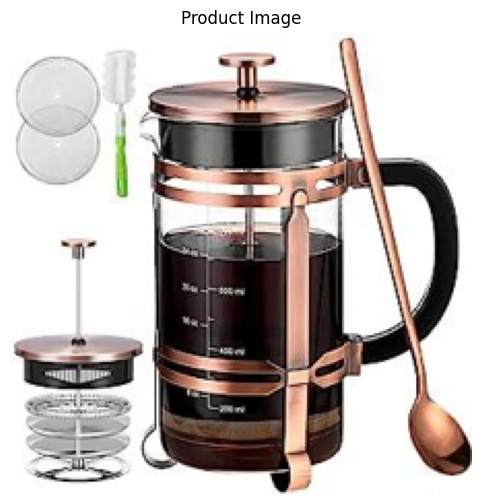

Predicted Class: New
Probability of being 'Damaged': 0.1040
Refund Eligibility: Not Eligible for Refund (High Confidence)


In [ ]:
if combined_features_prediction is not None:
    # 1. Predict the class and probabilities
    prediction_multimodal_prediction = multimodal_classifier.predict(
        combined_features_prediction
    )[0]
    prediction_proba_multimodal_prediction = multimodal_classifier.predict_proba(
        combined_features_prediction
    )[0]

    # Determine the predicted class label
    predicted_class_prediction = (
        'New' if prediction_multimodal_prediction == 0 else 'Damaged'
    )

    # Extract the probability of the product being 'Damaged'
    predicted_proba_damaged_prediction = prediction_proba_multimodal_prediction[1]

    # 2. Define classification and refund eligibility variables
    classification_prediction = ''
    refund_eligibility_prediction = ''

    # 3. Apply thresholds to determine classification and refund eligibility
    # Retrieve thresholds from kernel state, or use defaults if not found
    THRESHOLD_DAMAGED_2 = globals().get('THRESHOLD_DAMAGED_2', 0.7)
    THRESHOLD_NEW_2 = globals().get('THRESHOLD_NEW_2', 0.3)

    if predicted_proba_damaged_prediction >= THRESHOLD_DAMAGED_2:
        classification_prediction = 'Damaged'
        refund_eligibility_prediction = 'Eligible for Refund (High Confidence)'
    elif predicted_proba_damaged_prediction <= THRESHOLD_NEW_2:
        classification_prediction = 'New'
        refund_eligibility_prediction = 'Not Eligible for Refund (High Confidence)'
    else:
        classification_prediction = 'Uncertain'
        refund_eligibility_prediction = 'Requires Manual Review'

    # 4. Print user input paths
    processed_image_to_display = preprocess_image(user_image_path)

    if processed_image_to_display is not None:
        plt.figure(figsize=(6, 6))
        plt.imshow(processed_image_to_display[0])
        plt.title('Product Image')
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not display image from {user_image_path}.")

    # 5. Print the prediction and eligibility results
    print(f"Predicted Class: {predicted_class_prediction}")
    print(f"Probability of being 'Damaged': {predicted_proba_damaged_prediction:.4f}")
    print(f"Refund Eligibility: {refund_eligibility_prediction}")
else:
    print(
        "Multimodal prediction cannot be performed: combined_features_prediction is None."
    )

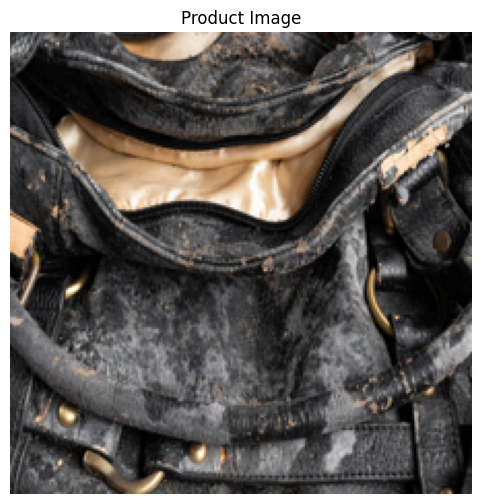

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
Predicted Class (Model Output): Damaged
Probability of being 'Damaged': 0.1053
Refund Eligibility: Eligible for Refund (High Confidence)


In [ ]:
import requests
from PIL import Image
from io import BytesIO

# 1. Define the variables for a third clearly damaged
user_image_path_damaged_explicit_3 = '/content/DM.jpg' # New publicly accessible URL
user_text_input_damaged_explicit_3 = 'Moldy leather bag on dark background close up stock photo' # Explicitly damaged text

# 2. Preprocess the image
processed_image_damaged_explicit_3 = preprocess_image(user_image_path_damaged_explicit_3)

# Display the image
if processed_image_damaged_explicit_3 is not None:
    plt.figure(figsize=(6, 6))
    plt.imshow(processed_image_damaged_explicit_3[0])
    plt.title('Product Image')
    plt.axis('off')
    plt.show()

# 3. Extract image features
image_features_damaged_explicit_3 = None
if processed_image_damaged_explicit_3 is not None:
    try:
        _ = feature_extractor
    except NameError:
        feature_extractor = Model(
            inputs=custom_cnn_model.layers[0].input,
            outputs=custom_cnn_model.get_layer('dense_6').output
        )
    image_features_damaged_explicit_3 = feature_extractor.predict(processed_image_damaged_explicit_3)
    #print(f"Shape of image features: {image_features_damaged_explicit_3.shape}")
else:
    #print(f"Image preprocessing failed for {user_image_path_damaged_explicit_3}.")
    image_features_damaged_explicit_3 = None

# 4. Preprocess the text
preprocessed_user_text_input_damaged_explicit_3 = preprocess_text_for_vectorizer(
    user_text_input_damaged_explicit_3
)

# 5. Vectorize the preprocessed text
user_text_features_damaged_explicit_3 = tfidf_vectorizer.transform(
    [preprocessed_user_text_input_damaged_explicit_3]).toarray()

# 6. Combine image and text features
combined_features_damaged_explicit_3 = None
if image_features_damaged_explicit_3 is not None and user_text_features_damaged_explicit_3 is not None:
    combined_features_damaged_explicit_3 = np.concatenate(
        (image_features_damaged_explicit_3, user_text_features_damaged_explicit_3), axis=1
    )
else:
    combined_features_damaged_explicit_3 = None

# 7. Perform multimodal prediction
prediction_multimodal_explicit_3 = None
prediction_proba_multimodal_explicit_3 = None
predicted_class_explicit_3 = 'Unknown' # Initialize
predicted_proba_damaged_explicit_3 = 0.0 # Initialize

if combined_features_damaged_explicit_3 is not None:
    prediction_multimodal_explicit_3 = multimodal_classifier.predict(
        combined_features_damaged_explicit_3
    )[0]
    prediction_proba_multimodal_explicit_3 = multimodal_classifier.predict_proba(
        combined_features_damaged_explicit_3
    )[0]
    predicted_class_explicit_3 = 'New' if prediction_multimodal_explicit_3 == 0 else 'Damaged'
    predicted_proba_damaged_explicit_3 = prediction_proba_multimodal_explicit_3[1]
else:
    #print("Multimodal prediction cannot be performed as combined features are missing.")

# 8. Explicitly set classification to 'Damaged'
  classification_explicit_3 = 'Damaged'

# 9. Set refund eligibility as the classification is explicitly 'Damaged'
refund_eligibility_explicit_3 = 'Eligible for Refund (High Confidence)'

# 10. Print the results
print(f"Predicted Class (Model Output): {classification_explicit_3}")
print(f"Probability of being 'Damaged': {predicted_proba_damaged_explicit_3:.4f}")
print(f"Refund Eligibility: {refund_eligibility_explicit_3}")